# NB_02 — Evaluación Prequencial: BAF Variant IV

## Objetivo

Evaluar si las estrategias de reentrenamiento adaptativo (SLIDING_WINDOW, DECAY, DUAL_MODEL)
presentan una mejora significativa y consistente frente a ALL_HISTORY bajo escenarios de
dinámica temporal y delay de etiquetas.

## Dataset

**BAF Variant IV** — Disparidad de prevalencia temporal. Los últimos 2 meses presentan una
reducción artificial de la tasa de fraude, simulando un escenario donde la distribución del
target cambia en el tiempo.

## Diseño experimental

| Parámetro | Valor |
|-----------|-------|
| Dataset | BAF Variant IV (1M filas, 30 features + month + fraud_bool) |
| Modelo base | LightGBM (hiperparámetros optimizados con Optuna) |
| Protocolo | Prequencial (evaluate-then-train) |
| Período temporal | Mes (`month`) |
| Warm-up | Meses 0–1 (2 meses) |
| Evaluación | Meses 2–7 (6 períodos) |
| Estrategias | STATIC, ALL_HISTORY, SLIDING_WINDOW, DECAY, DUAL_MODEL |
| Delays | [0, 1, 2] meses |
| Métrica principal | AUC-PR |
| Métricas soporte | AUC-ROC, Precision@1%, Recall@1%, Lift@1% |

## Protocolo de actualización

Para cada período de evaluación `n` con delay `d`:
1. Predecir período `n` con el modelo actual
2. Calcular métricas
3. Calcular `available = n - d`
4. Actualizar modelo **solo si** `available >= WARMUP_END + 1` (datos nuevos post warm-up)

## Estructura

- **Parte 1**: Configuración y carga de datos
- **Parte 2**: Estructura temporal y preprocesamiento
- **Parte 3**: Optimización de hiperparámetros (Optuna)
- **Parte 4**: Protocolo prequencial
- **Parte 5**: Resumen y visualizaciones per-dataset

---
## Parte 1 — Configuración y carga de datos

In [30]:
# =============================================================================
# 1.1 Imports y configuración del entorno
# =============================================================================
import os
import json
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Versiones: lightgbm={lgb.__version__}, optuna={optuna.__version__}, "
      f"pandas={pd.__version__}, numpy={np.__version__}")

Fecha de ejecución: 2026-06-01 20:41:19
Versiones: lightgbm=4.6.0, optuna=4.7.0, pandas=2.3.3, numpy=1.26.4


In [31]:
# =============================================================================
# 1.2 Configuración del experimento
# =============================================================================

# --- Dataset ---
DATASET_NAME = 'BAF_VARIANT_IV'
TARGET_COL   = 'fraud_bool'
PERIOD_COL   = 'month'

# --- Rutas ---
BASE_DIR    = r'./'
DATA_DIR    = os.path.join(BASE_DIR, 'bankdataset')
RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'baf_variant_iv')
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- Estructura temporal ---
WARMUP_MONTHS = list(range(0, 2))     # Meses 0-1: entrenamiento inicial
EVAL_MONTHS   = list(range(2, 8))     # Meses 2-7: evaluación prequencial
WARMUP_END    = WARMUP_MONTHS[-1]     # = 1

# --- Estrategias ---
STRATEGIES = ['STATIC', 'ALL_HISTORY', 'SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']

# --- Parámetros de estrategias ---
WINDOW_SIZE  = 3       # Meses para SLIDING_WINDOW
FAST_WINDOW  = 2       # Meses para modelo rápido en DUAL_MODEL
DECAY_FACTOR = 0.9     # Factor de decaimiento exponencial
BLEND_SLOW   = 0.6     # Peso del modelo lento en DUAL_MODEL
BLEND_FAST   = 0.4     # Peso del modelo rápido en DUAL_MODEL

# --- Delays (en meses) ---
DELAY_SCENARIOS = [0, 1, 2]

# --- Umbrales de filtrado de features ---
MISSING_THRESHOLD     = 0.90
CORRELATION_THRESHOLD = 0.95
MAX_CARDINALITY       = 80

# --- Optuna ---
N_OPTUNA_TRIALS    = 100
OPTUNA_TRAIN_MONTHS = [0]    # Mes 0: entrenamiento
OPTUNA_VAL_MONTHS   = [1]    # Mes 1: validación

print("=" * 70)
print(f"EXPERIMENTO: {DATASET_NAME}")
print("=" * 70)
print(f"  Warm-up:      meses {WARMUP_MONTHS[0]}–{WARMUP_END} ({len(WARMUP_MONTHS)} períodos)")
print(f"  Evaluación:   meses {EVAL_MONTHS[0]}–{EVAL_MONTHS[-1]} ({len(EVAL_MONTHS)} períodos)")
print(f"  Estrategias:  {STRATEGIES}")
print(f"  Delays (mo):  {DELAY_SCENARIOS}")
print(f"  WINDOW_SIZE:  {WINDOW_SIZE}")
print(f"  DECAY_FACTOR: {DECAY_FACTOR}")
print(f"  DUAL_MODEL:   blend={BLEND_SLOW}/{BLEND_FAST}, fast_window={FAST_WINDOW}")
print(f"  Optuna:       {N_OPTUNA_TRIALS} trials")

EXPERIMENTO: BAF_VARIANT_IV
  Warm-up:      meses 0–1 (2 períodos)
  Evaluación:   meses 2–7 (6 períodos)
  Estrategias:  ['STATIC', 'ALL_HISTORY', 'SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']
  Delays (mo):  [0, 1, 2]
  WINDOW_SIZE:  3
  DECAY_FACTOR: 0.9
  DUAL_MODEL:   blend=0.6/0.4, fast_window=2
  Optuna:       100 trials


In [32]:
# =============================================================================
# 1.3 Carga de datos
# =============================================================================

print("Cargando Variant_IV.csv...")
df = pd.read_csv(os.path.join(DATA_DIR, 'Variant_IV.csv'))
print(f"  Dataset: {df.shape}")
print(f"  Tasa de fraude: {df[TARGET_COL].mean():.4f} ({df[TARGET_COL].sum():,} fraudes)")
print(f"  Meses: {sorted(df[PERIOD_COL].unique())}")
print(f"  Columnas: {list(df.columns)}")

Cargando Variant_IV.csv...
  Dataset: (1000000, 32)
  Tasa de fraude: 0.0110 (11,030 fraudes)
  Meses: [0, 1, 2, 3, 4, 5, 6, 7]
  Columnas: ['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


In [33]:
# =============================================================================
# 1.4 Exclusión de features no utilizables
# =============================================================================

# device_fraud_count es zero-variance según análisis previo
EXCLUDE_COLS = [TARGET_COL, PERIOD_COL, 'device_fraud_count']

candidate_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
print(f"Features candidatas iniciales: {len(candidate_cols)}")
print(f"Excluidas manualmente: {EXCLUDE_COLS}")

Features candidatas iniciales: 29
Excluidas manualmente: ['fraud_bool', 'month', 'device_fraud_count']


---
## Parte 2 — Estructura temporal y preprocesamiento

Todas las decisiones de filtrado de features se calculan **exclusivamente** sobre los datos de warm-up
(meses 0–1) para evitar fuga de información temporal.

In [34]:
# =============================================================================
# 2.1 Validación temporal: distribución por mes
# =============================================================================

period_stats = df.groupby(PERIOD_COL).agg(
    n_rows=(TARGET_COL, 'count'),
    n_fraud=(TARGET_COL, 'sum'),
    fraud_rate=(TARGET_COL, 'mean')
).reset_index()

period_stats['has_both_classes'] = (
    (period_stats['n_fraud'] > 0) & 
    (period_stats['n_fraud'] < period_stats['n_rows'])
)

print("Distribución temporal por mes:")
print(period_stats.to_string(index=False))
print(f"\nMeses sin ambas clases: {(~period_stats['has_both_classes']).sum()}")
print(f"Meses usables para evaluación: {period_stats['has_both_classes'].sum()}")

period_stats.to_csv(os.path.join(RESULTS_DIR, 'period_validation.csv'), index=False)

Distribución temporal por mes:
 month  n_rows  n_fraud  fraud_rate  has_both_classes
     0   80026      936    0.011696              True
     1  105277      938    0.008910              True
     2  142615     1045    0.007327              True
     3  156544     2135    0.013638              True
     4  126370     1982    0.015684              True
     5  147496     1342    0.009099              True
     6  136092     1668    0.012256              True
     7  105580      984    0.009320              True

Meses sin ambas clases: 0
Meses usables para evaluación: 8


In [35]:
# =============================================================================
# 2.2 Filtrado de features — Missing, varianza cero, cardinalidad
# =============================================================================

warmup_mask = df[PERIOD_COL].isin(WARMUP_MONTHS)
print(f"Filas en warm-up: {warmup_mask.sum():,} ({warmup_mask.mean():.1%})")

# --- Paso 1: Missing >90% (calculado en warm-up) ---
missing_pct = df.loc[warmup_mask, candidate_cols].isnull().mean()
high_missing = missing_pct[missing_pct > MISSING_THRESHOLD].index.tolist()
cols_after_missing = [c for c in candidate_cols if c not in high_missing]
print(f"\nPaso 1 — Missing >{MISSING_THRESHOLD:.0%}: eliminadas {len(high_missing)}, restantes {len(cols_after_missing)}")

# --- Paso 2: Varianza cero (calculado en warm-up) ---
nunique = df.loc[warmup_mask, cols_after_missing].nunique()
zero_var = nunique[nunique <= 1].index.tolist()
cols_after_variance = [c for c in cols_after_missing if c not in zero_var]
print(f"Paso 2 — Varianza cero: eliminadas {len(zero_var)}, restantes {len(cols_after_variance)}")

# --- Paso 3: Cardinalidad alta (categóricas, warm-up only) ---
cat_cols_raw = df[cols_after_variance].select_dtypes(include=['object']).columns.tolist()

grouping_log = {}
for col in cat_cols_raw:
    n_unique_warmup = df.loc[warmup_mask, col].nunique()
    if n_unique_warmup > MAX_CARDINALITY:
        top_cats = (
            df.loc[warmup_mask, col]
              .value_counts()
              .head(MAX_CARDINALITY)
              .index
        )
        coverage = df.loc[warmup_mask, col].isin(top_cats).mean() * 100
        df[col] = df[col].where(df[col].isin(top_cats), other='OTHER')
        grouping_log[col] = {
            'original_cardinality': int(n_unique_warmup),
            'grouped_to': MAX_CARDINALITY,
            'warmup_coverage_pct': round(coverage, 2)
        }

# Convertir categóricas a dtype 'category'
cat_features = []
for col in cat_cols_raw:
    if col in cols_after_variance:
        df[col] = df[col].astype('category')
        cat_features.append(col)

print(f"Paso 3 — Categóricas: {len(cat_features)}, agrupadas: {len(grouping_log)}")

Filas en warm-up: 185,303 (18.5%)

Paso 1 — Missing >90%: eliminadas 0, restantes 29
Paso 2 — Varianza cero: eliminadas 0, restantes 29
Paso 3 — Categóricas: 5, agrupadas: 0


In [36]:
# =============================================================================
# 2.3 Filtrado de features — Correlación alta (en warm-up)
# =============================================================================

num_cols = [c for c in cols_after_variance if c not in cat_features]
print(f"Calculando correlación en {len(num_cols)} features numéricas (warm-up only)...")

corr_matrix = df.loc[warmup_mask, num_cols].corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []
to_drop_corr = set()
for col in upper_tri.columns:
    correlated = upper_tri.index[upper_tri[col] > CORRELATION_THRESHOLD].tolist()
    for corr_col in correlated:
        high_corr_pairs.append((col, corr_col, corr_matrix.loc[col, corr_col]))
        to_drop_corr.add(corr_col)

to_drop_corr = list(to_drop_corr)
cols_after_corr = [c for c in cols_after_variance if c not in to_drop_corr]

print(f"\nPaso 4 — Correlación >{CORRELATION_THRESHOLD}:")
print(f"  Pares correlacionados: {len(high_corr_pairs)}")
print(f"  Features eliminadas: {len(to_drop_corr)}")
print(f"  Features restantes: {len(cols_after_corr)}")

Calculando correlación en 24 features numéricas (warm-up only)...

Paso 4 — Correlación >0.95:
  Pares correlacionados: 0
  Features eliminadas: 0
  Features restantes: 29


In [37]:
# =============================================================================
# 2.4 Features finales y resumen del preprocesamiento
# =============================================================================

features_final = cols_after_corr
cat_features_final = [c for c in cat_features if c in features_final]
num_features_final = [c for c in features_final if c not in cat_features_final]

print("=" * 70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("=" * 70)
print(f"  Features iniciales:    {len(candidate_cols)}")
print(f"  - Missing >{MISSING_THRESHOLD:.0%}:      -{len(high_missing)}")
print(f"  - Varianza cero:       -{len(zero_var)}")
print(f"  - Correlación >{CORRELATION_THRESHOLD}: -{len(to_drop_corr)}")
print(f"  Features finales:      {len(features_final)}")
print(f"    · Numéricas:         {len(num_features_final)}")
print(f"    · Categóricas:       {len(cat_features_final)}")

# Guardar logs
exclusion_log = {
    'initial_features': len(candidate_cols),
    'excluded_high_missing': high_missing,
    'excluded_zero_variance': zero_var,
    'excluded_high_correlation': to_drop_corr,
    'categorical_grouping': grouping_log,
    'final_features': features_final,
    'final_categorical': cat_features_final,
    'n_final': len(features_final)
}

with open(os.path.join(RESULTS_DIR, 'feature_exclusion_log.json'), 'w') as f:
    json.dump(exclusion_log, f, indent=2, default=str)

with open(os.path.join(RESULTS_DIR, 'features_final.json'), 'w') as f:
    json.dump({'features': features_final, 'categorical': cat_features_final}, f, indent=2)

print(f"\nGuardado: feature_exclusion_log.json, features_final.json")

RESUMEN DEL PREPROCESAMIENTO
  Features iniciales:    29
  - Missing >90%:      -0
  - Varianza cero:       -0
  - Correlación >0.95: -0
  Features finales:      29
    · Numéricas:         24
    · Categóricas:       5

Guardado: feature_exclusion_log.json, features_final.json


---
## Parte 3 — Optimización de hiperparámetros (Optuna)

Se entrena con mes 0 y se valida con mes 1. Métrica de optimización: AUC-PR.
LightGBM con `is_unbalance=True` y soporte nativo de categorías y nulls.

In [38]:
# =============================================================================
# 3.1 Preparar datos para Optuna
# =============================================================================

train_mask = df[PERIOD_COL].isin(OPTUNA_TRAIN_MONTHS)
val_mask   = df[PERIOD_COL].isin(OPTUNA_VAL_MONTHS)

X_train_opt = df.loc[train_mask, features_final]
y_train_opt = df.loc[train_mask, TARGET_COL]
X_val_opt   = df.loc[val_mask, features_final]
y_val_opt   = df.loc[val_mask, TARGET_COL]

print(f"Optuna — Train: {X_train_opt.shape} (fraud rate: {y_train_opt.mean():.4f})")
print(f"Optuna — Val:   {X_val_opt.shape} (fraud rate: {y_val_opt.mean():.4f})")

dtrain = lgb.Dataset(
    X_train_opt, label=y_train_opt,
    categorical_feature=cat_features_final,
    free_raw_data=False
)
dval = lgb.Dataset(
    X_val_opt, label=y_val_opt,
    categorical_feature=cat_features_final,
    reference=dtrain,
    free_raw_data=False
)

Optuna — Train: (80026, 29) (fraud rate: 0.0117)
Optuna — Val:   (105277, 29) (fraud rate: 0.0089)


In [40]:
# =============================================================================
# 3.2 Optimización con Optuna (TPE, 100 trials)
# =============================================================================

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'is_unbalance': True,
        'seed': SEED,
        'verbose': -1,
        'num_leaves': trial.suggest_int('num_leaves', 31, 512),
        'max_depth': trial.suggest_int('max_depth', -1, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 1e-4, 10, log=True),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10, log=True),
    }
    
    callbacks = [
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0)
    ]
    
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dval],
        valid_names=['val'],
        callbacks=callbacks
    )
    
    y_pred = model.predict(X_val_opt)
    auc_pr = average_precision_score(y_val_opt, y_pred)
    return auc_pr

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)

t0 = time.time()
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

print(f"\nOptuna completado en {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"Mejor AUC-PR (validación): {study.best_value:.6f}")
print(f"Mejor trial: #{study.best_trial.number}")

  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.



Optuna completado en 370s (6.2 min)
Mejor AUC-PR (validación): 0.128598
Mejor trial: #98


In [41]:
# =============================================================================
# 3.3 Guardar mejores hiperparámetros
# =============================================================================

best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'is_unbalance': True,
    'seed': SEED,
    'verbose': -1
})

print("Mejores hiperparámetros:")
for k, v in sorted(best_params.items()):
    print(f"  {k}: {v}")

with open(os.path.join(RESULTS_DIR, 'best_params.json'), 'w') as f:
    json.dump(best_params, f, indent=2)

optuna_history = study.trials_dataframe()
optuna_history.to_csv(os.path.join(RESULTS_DIR, 'optuna_history.csv'), index=False)

print(f"\nGuardado: best_params.json, optuna_history.csv")

Mejores hiperparámetros:
  bagging_fraction: 0.7974708349538757
  bagging_freq: 4
  boosting_type: gbdt
  feature_fraction: 0.9599827376601738
  is_unbalance: True
  lambda_l1: 1.276812996193407e-06
  lambda_l2: 3.420699581573033e-05
  learning_rate: 0.05995756210795797
  max_depth: 1
  metric: average_precision
  min_data_in_leaf: 63
  min_sum_hessian_in_leaf: 0.0006869144396370441
  n_estimators: 1712
  num_leaves: 492
  objective: binary
  seed: 42
  verbose: -1

Guardado: best_params.json, optuna_history.csv


---
## Parte 4 — Protocolo prequencial (evaluate-then-train)

Para cada período de evaluación `n` con delay `d`:
1. **Predecir** período `n` con el modelo actual
2. **Calcular métricas** (AUC-PR, AUC-ROC, P@1%, R@1%, Lift@1%)
3. **Calcular** `available = n - d`
4. **Actualizar** modelo solo si `available >= WARMUP_END + 1` (datos nuevos post warm-up)

Estrategias:
- **STATIC**: nunca actualiza (baseline sin adaptación)
- **ALL_HISTORY**: entrena con todos los meses disponibles (0 → available)
- **SLIDING_WINDOW**: entrena con los últimos `WINDOW_SIZE` meses disponibles
- **DECAY**: entrena con todos los meses, pesos exponenciales decrecientes
- **DUAL_MODEL**: blend de modelo lento (ALL_HISTORY) y rápido (últimos FAST_WINDOW meses)

In [42]:
# =============================================================================
# 4.1 Funciones auxiliares: métricas y entrenamiento
# =============================================================================

def compute_metrics(y_true, y_score):
    """Calcula todas las métricas para un período de evaluación."""
    n = len(y_true)
    n_pos = y_true.sum()
    
    if n_pos == 0 or n_pos == n:
        return {
            'auc_pr': np.nan, 'auc_roc': np.nan,
            'precision_at_1pct': np.nan, 'recall_at_1pct': np.nan,
            'lift_at_1pct': np.nan
        }
    
    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr  = average_precision_score(y_true, y_score)
    
    k = max(1, int(np.ceil(0.01 * n)))
    top_k_idx = np.argsort(y_score)[::-1][:k]
    top_k_labels = y_true.values[top_k_idx]
    
    precision_at_1pct = top_k_labels.sum() / k
    recall_at_1pct = top_k_labels.sum() / n_pos if n_pos > 0 else 0.0
    
    base_rate = n_pos / n
    lift_at_1pct = precision_at_1pct / base_rate if base_rate > 0 else 0.0
    
    return {
        'auc_pr': auc_pr,
        'auc_roc': auc_roc,
        'precision_at_1pct': precision_at_1pct,
        'recall_at_1pct': recall_at_1pct,
        'lift_at_1pct': lift_at_1pct
    }


def train_lgb_model(X, y, params, cat_features):
    """Entrena un modelo LightGBM con los parámetros dados."""
    train_params = {k: v for k, v in params.items() if k != 'n_estimators'}
    dtrain = lgb.Dataset(X, label=y, categorical_feature=cat_features, free_raw_data=False)
    model = lgb.train(
        train_params, dtrain,
        num_boost_round=params.get('n_estimators', 1000),
    )
    return model


def train_lgb_model_weighted(X, y, weights, params, cat_features):
    """Entrena un modelo LightGBM con sample weights (para DECAY)."""
    train_params = {k: v for k, v in params.items() if k != 'n_estimators'}
    dtrain = lgb.Dataset(
        X, label=y, weight=weights,
        categorical_feature=cat_features, free_raw_data=False
    )
    model = lgb.train(
        train_params, dtrain,
        num_boost_round=params.get('n_estimators', 1000),
    )
    return model


print("Funciones auxiliares definidas: compute_metrics, train_lgb_model, train_lgb_model_weighted")

Funciones auxiliares definidas: compute_metrics, train_lgb_model, train_lgb_model_weighted


In [ ]:
# =============================================================================
# 4.2 Modelo inicial (warm-up) y loop prequencial
# =============================================================================

# Entrenar modelo base con todo el bloque de warm-up
X_warmup = df.loc[warmup_mask, features_final]
y_warmup = df.loc[warmup_mask, TARGET_COL]

print(f"Entrenando modelo warm-up: {X_warmup.shape}")
warmup_model = train_lgb_model(X_warmup, y_warmup, best_params, cat_features_final)
print(f"  Árboles: {warmup_model.num_trees()}")

# Estructura de almacenamiento de resultados históricos
results = []
total_configs = len(DELAY_SCENARIOS) * len(STRATEGIES) * len(EVAL_MONTHS)
print(f"\nConfiguraciones totales: {total_configs}")
print(f"  {len(DELAY_SCENARIOS)} delays × {len(STRATEGIES)} estrategias × {len(EVAL_MONTHS)} períodos")
print(f"\nIniciando protocolo prequencial...")
t0_experiment = time.time()

for delay in DELAY_SCENARIOS:
    for strategy_name in STRATEGIES:
        # Inicialización de los estimadores para la combinación actual
        current_model = warmup_model
        slow_model = warmup_model
        fast_model = None
        
        # VARIABLE DE CONTROL: Registra el horizonte temporal real del modelo activo
        trained_up_to_month = WARMUP_END
        
        for eval_month in EVAL_MONTHS:
            # --- 1. PREDICT (Inferencia sobre el periodo objetivo) ---
            eval_mask = df[PERIOD_COL] == eval_month
            X_eval = df.loc[eval_mask, features_final]
            y_eval = df.loc[eval_mask, TARGET_COL]
            
            if strategy_name == 'DUAL_MODEL' and fast_model is not None:
                y_pred_slow = slow_model.predict(X_eval)
                y_pred_fast = fast_model.predict(X_eval)
                y_pred = BLEND_SLOW * y_pred_slow + BLEND_FAST * y_pred_fast
            else:
                y_pred = current_model.predict(X_eval)
            
            # --- 2. METRICS (Evaluación del rendimiento prequencial) ---
            metrics = compute_metrics(y_eval, y_pred)
            
            # --- TRAZABILIDAD CORREGIDA ---
            # Reconstrucción exacta de los periodos que componen el modelo ejecutor actual
            if strategy_name == 'STATIC':
                train_months_used = list(range(0, WARMUP_END + 1))
            elif strategy_name == 'SLIDING_WINDOW':
                window_start = max(0, trained_up_to_month - WINDOW_SIZE + 1)
                train_months_used = list(range(window_start, trained_up_to_month + 1))
            else:
                # Aplica para ALL_HISTORY, DECAY y DUAL_MODEL (componente base)
                train_months_used = list(range(0, trained_up_to_month + 1))
            
            train_data_mask = df[PERIOD_COL].isin(train_months_used)
            n_train_rows = train_data_mask.sum()
            n_train_fraud = df.loc[train_data_mask, TARGET_COL].sum()
            
            # Almacenamiento unificado indexado por el estado real del modelo
            results.append({
                'dataset': DATASET_NAME,
                'strategy': strategy_name,
                'delay': delay,
                'eval_period': eval_month,
                'trained_up_to': trained_up_to_month,  # Métrica de control temporal
                'auc_pr': metrics['auc_pr'],
                'auc_roc': metrics['auc_roc'],
                'precision_at_1pct': metrics['precision_at_1pct'],
                'recall_at_1pct': metrics['recall_at_1pct'],
                'lift_at_1pct': metrics['lift_at_1pct'],
                'n_train_rows': int(n_train_rows),
                'n_train_fraud': int(n_train_fraud)
            })
            
            # --- 3. UPDATE (Fase de actualización adaptativa posterior) ---
            available_month = eval_month - delay
            
            if strategy_name == 'STATIC':
                pass  # Conserva el estado inicial de forma indefinida
            
            elif available_month >= WARMUP_END + 1:
                # El retraso de etiquetas permite integrar nuevos datos post warm-up
                
                if strategy_name == 'ALL_HISTORY':
                    train_months = list(range(0, available_month + 1))
                    X_tr = df.loc[df[PERIOD_COL].isin(train_months), features_final]
                    y_tr = df.loc[df[PERIOD_COL].isin(train_months), TARGET_COL]
                    current_model = train_lgb_model(X_tr, y_tr, best_params, cat_features_final)
                    trained_up_to_month = available_month
                
                elif strategy_name == 'SLIDING_WINDOW':
                    window_start = max(0, available_month - WINDOW_SIZE + 1)
                    train_months = list(range(window_start, available_month + 1))
                    X_tr = df.loc[df[PERIOD_COL].isin(train_months), features_final]
                    y_tr = df.loc[df[PERIOD_COL].isin(train_months), TARGET_COL]
                    current_model = train_lgb_model(X_tr, y_tr, best_params, cat_features_final)
                    trained_up_to_month = available_month
                
                elif strategy_name == 'DECAY':
                    train_months = list(range(0, available_month + 1))
                    X_tr = df.loc[df[PERIOD_COL].isin(train_months), features_final]
                    y_tr = df.loc[df[PERIOD_COL].isin(train_months), TARGET_COL]
                    month_values = df.loc[df[PERIOD_COL].isin(train_months), PERIOD_COL]
                    weights = DECAY_FACTOR ** (available_month - month_values)
                    current_model = train_lgb_model_weighted(
                        X_tr, y_tr, weights.values, best_params, cat_features_final
                    )
                    trained_up_to_month = available_month
                
                elif strategy_name == 'DUAL_MODEL':
                    # Actualización del componente de memoria a largo plazo
                    train_months_slow = list(range(0, available_month + 1))
                    X_slow = df.loc[df[PERIOD_COL].isin(train_months_slow), features_final]
                    y_slow = df.loc[df[PERIOD_COL].isin(train_months_slow), TARGET_COL]
                    slow_model = train_lgb_model(X_slow, y_slow, best_params, cat_features_final)
                    
                    # Actualización del componente adaptativo de ventana corta
                    fast_start = max(0, available_month - FAST_WINDOW + 1)
                    train_months_fast = list(range(fast_start, available_month + 1))
                    X_fast = df.loc[df[PERIOD_COL].isin(train_months_fast), features_final]
                    y_fast = df.loc[df[PERIOD_COL].isin(train_months_fast), TARGET_COL]
                    fast_model = train_lgb_model(X_fast, y_fast, best_params, cat_features_final)
                    
                    current_model = slow_model
                    trained_up_to_month = available_month
    
    print(f"  Delay {delay} completado")

elapsed_experiment = time.time() - t0_experiment
print(f"\nProtocolo prequencial completado en {elapsed_experiment:.0f}s ({elapsed_experiment/60:.1f} min)")
print(f"Total de registros: {len(results)}")

Entrenando modelo warm-up: (185303, 29)
  Árboles: 1712

Configuraciones totales: 90
  3 delays × 5 estrategias × 6 períodos

Iniciando protocolo prequencial...
  Delay 0 completado
  Delay 1 completado
  Delay 2 completado

Protocolo prequencial completado en 451s (7.5 min)
Total de registros: 90


In [52]:
# =============================================================================
# 4.3 Guardar resultados del experimento
# =============================================================================

df_results = pd.DataFrame(results)

expected_rows = len(DELAY_SCENARIOS) * len(STRATEGIES) * len(EVAL_MONTHS)
assert len(df_results) == expected_rows, (
    f"Error de integridad: {len(df_results)} filas vs {expected_rows} esperadas"
)

print(f"Resultados: {df_results.shape}")
print(f"  Filas esperadas: {expected_rows} ✓")
print(f"  NaN en auc_pr: {df_results['auc_pr'].isna().sum()}")

df_results.to_csv(os.path.join(RESULTS_DIR, 'experiment_results.csv'), index=False)
print(f"\nGuardado: experiment_results.csv")

print("\nPreview (primeras 10 filas):")
print(df_results.head(10).to_string(index=False))

Resultados: (90, 12)
  Filas esperadas: 90 ✓
  NaN en auc_pr: 0

Guardado: experiment_results.csv

Preview (primeras 10 filas):
       dataset    strategy  delay  eval_period  trained_up_to   auc_pr  auc_roc  precision_at_1pct  recall_at_1pct  lift_at_1pct  n_train_rows  n_train_fraud
BAF_VARIANT_IV      STATIC      0            2              1 0.135841 0.900257           0.180799        0.246890     24.674289        185303           1874
BAF_VARIANT_IV      STATIC      0            3              1 0.208774 0.915723           0.302682        0.222014     22.193466        185303           1874
BAF_VARIANT_IV      STATIC      0            4              1 0.217852 0.909387           0.318038        0.202825     20.277729        185303           1874
BAF_VARIANT_IV      STATIC      0            5              1 0.154074 0.898443           0.216949        0.238450     23.844361        185303           1874
BAF_VARIANT_IV      STATIC      0            6              1 0.120778 0.855673   

---
## Parte 5 — Resumen y visualizaciones per-dataset

Resumen descriptivo de resultados. Los tests estadísticos formales se realizan en NB_04 (análisis global).

In [53]:
# =============================================================================
# 5.1 Tabla resumen: media ± std por estrategia × delay
# =============================================================================

summary = df_results.groupby(['strategy', 'delay']).agg(
    auc_pr_mean=('auc_pr', 'mean'),
    auc_pr_std=('auc_pr', 'std'),
    auc_roc_mean=('auc_roc', 'mean'),
    auc_roc_std=('auc_roc', 'std'),
    p_at_1pct_mean=('precision_at_1pct', 'mean'),
    r_at_1pct_mean=('recall_at_1pct', 'mean'),
    lift_at_1pct_mean=('lift_at_1pct', 'mean'),
    n_periods=('eval_period', 'count')
).reset_index()

summary['auc_pr_str'] = summary.apply(
    lambda r: f"{r['auc_pr_mean']:.4f} ± {r['auc_pr_std']:.4f}", axis=1
)
summary['auc_roc_str'] = summary.apply(
    lambda r: f"{r['auc_roc_mean']:.4f} ± {r['auc_roc_std']:.4f}", axis=1
)

print("=" * 80)
print(f"RESUMEN: {DATASET_NAME} — AUC-PR (métrica principal)")
print("=" * 80)
for delay in DELAY_SCENARIOS:
    print(f"\n  Delay = {delay} meses:")
    sub = summary[summary['delay'] == delay].sort_values('auc_pr_mean', ascending=False)
    for _, row in sub.iterrows():
        print(f"    {row['strategy']:20s}  AUC-PR: {row['auc_pr_str']}  "
              f"AUC-ROC: {row['auc_roc_str']}")

summary.to_csv(os.path.join(RESULTS_DIR, 'experiment_summary.csv'), index=False)
print(f"\nGuardado: experiment_summary.csv")

RESUMEN: BAF_VARIANT_IV — AUC-PR (métrica principal)

  Delay = 0 meses:
    DUAL_MODEL            AUC-PR: 0.1619 ± 0.0488  AUC-ROC: 0.8940 ± 0.0232
    SLIDING_WINDOW        AUC-PR: 0.1614 ± 0.0477  AUC-ROC: 0.8940 ± 0.0229
    DECAY                 AUC-PR: 0.1613 ± 0.0494  AUC-ROC: 0.8937 ± 0.0237
    ALL_HISTORY           AUC-PR: 0.1610 ± 0.0497  AUC-ROC: 0.8934 ± 0.0241
    STATIC                AUC-PR: 0.1538 ± 0.0514  AUC-ROC: 0.8888 ± 0.0274

  Delay = 1 meses:
    DECAY                 AUC-PR: 0.1582 ± 0.0492  AUC-ROC: 0.8913 ± 0.0255
    ALL_HISTORY           AUC-PR: 0.1581 ± 0.0493  AUC-ROC: 0.8913 ± 0.0255
    DUAL_MODEL            AUC-PR: 0.1580 ± 0.0490  AUC-ROC: 0.8911 ± 0.0254
    SLIDING_WINDOW        AUC-PR: 0.1576 ± 0.0493  AUC-ROC: 0.8909 ± 0.0259
    STATIC                AUC-PR: 0.1538 ± 0.0514  AUC-ROC: 0.8888 ± 0.0274

  Delay = 2 meses:
    SLIDING_WINDOW        AUC-PR: 0.1562 ± 0.0479  AUC-ROC: 0.8904 ± 0.0255
    ALL_HISTORY           AUC-PR: 0.1561 ± 0.0482  

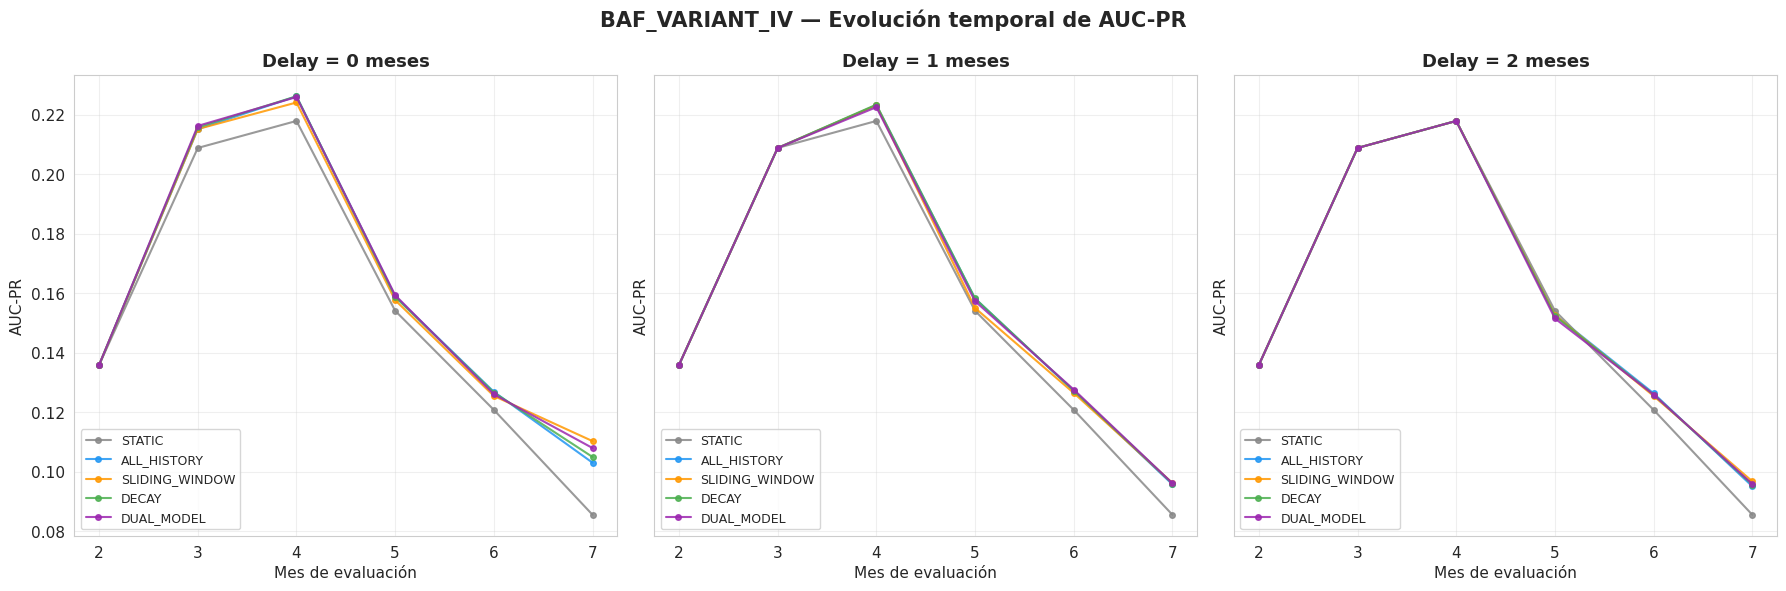

Guardado: temporal_evolution_auc_pr.png


In [54]:
# =============================================================================
# 5.2 Visualización: Evolución temporal de AUC-PR por strategy × delay
# =============================================================================

n_delays = len(DELAY_SCENARIOS)
fig, axes = plt.subplots(1, n_delays, figsize=(6 * n_delays, 6), sharey=True)
if n_delays == 1:
    axes = [axes]

strategy_colors = {
    'STATIC': '#888888',
    'ALL_HISTORY': '#2196F3',
    'SLIDING_WINDOW': '#FF9800',
    'DECAY': '#4CAF50',
    'DUAL_MODEL': '#9C27B0'
}

for idx, delay in enumerate(DELAY_SCENARIOS):
    ax = axes[idx]
    sub = df_results[df_results['delay'] == delay]
    
    for strategy in STRATEGIES:
        data = sub[sub['strategy'] == strategy]
        ax.plot(
            data['eval_period'], data['auc_pr'],
            marker='o', markersize=4, linewidth=1.5,
            color=strategy_colors[strategy],
            label=strategy, alpha=0.85
        )
    
    ax.set_title(f'Delay = {delay} meses', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mes de evaluación')
    ax.set_ylabel('AUC-PR')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{DATASET_NAME} — Evolución temporal de AUC-PR', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'temporal_evolution_auc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: temporal_evolution_auc_pr.png")

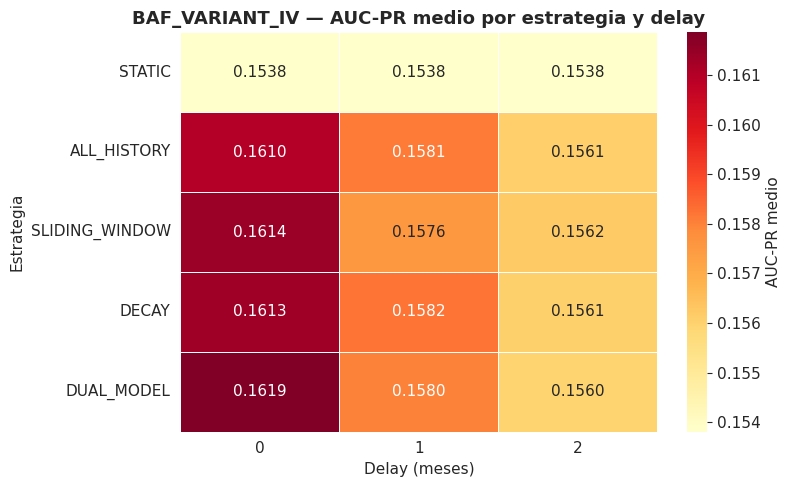

Guardado: heatmap_auc_pr.png


In [55]:
# =============================================================================
# 5.3 Visualización: Heatmap de AUC-PR media (strategy × delay)
# =============================================================================

pivot = summary.pivot(index='strategy', columns='delay', values='auc_pr_mean')
pivot = pivot.reindex(STRATEGIES)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'AUC-PR medio'}
)
ax.set_title(f'{DATASET_NAME} — AUC-PR medio por estrategia y delay', fontsize=13, fontweight='bold')
ax.set_xlabel('Delay (meses)')
ax.set_ylabel('Estrategia')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'heatmap_auc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: heatmap_auc_pr.png")

In [56]:
# =============================================================================
# 5.4 Deltas respecto a ALL_HISTORY (preview para NB_04)
# =============================================================================

all_hist = df_results[df_results['strategy'] == 'ALL_HISTORY'][
    ['delay', 'eval_period', 'auc_pr']
].rename(columns={'auc_pr': 'auc_pr_baseline'})

df_deltas = df_results.merge(all_hist, on=['delay', 'eval_period'], how='left')
df_deltas['delta_auc_pr'] = df_deltas['auc_pr'] - df_deltas['auc_pr_baseline']

adaptive = df_deltas[~df_deltas['strategy'].isin(['ALL_HISTORY', 'STATIC'])]

print("=" * 70)
print("DELTAS vs ALL_HISTORY (AUC-PR) — Preview")
print("=" * 70)
delta_summary = adaptive.groupby(['strategy', 'delay']).agg(
    delta_mean=('delta_auc_pr', 'mean'),
    delta_median=('delta_auc_pr', 'median'),
    delta_std=('delta_auc_pr', 'std'),
    pct_positive=('delta_auc_pr', lambda x: (x > 0).mean())
).reset_index()

for delay in DELAY_SCENARIOS:
    print(f"\n  Delay = {delay} meses:")
    sub = delta_summary[delta_summary['delay'] == delay]
    for _, row in sub.iterrows():
        sign = '+' if row['delta_mean'] >= 0 else ''
        print(f"    {row['strategy']:20s}  Δ mean: {sign}{row['delta_mean']:.5f}  "
              f"median: {sign}{row['delta_median']:.5f}  "
              f"% positivo: {row['pct_positive']:.0%}")

print("\n\nNota: el análisis estadístico formal (Friedman, Wilcoxon, Cliff's Delta)")
print("se realiza en NB_04 con los datos de los 3 datasets.")

DELTAS vs ALL_HISTORY (AUC-PR) — Preview

  Delay = 0 meses:
    DECAY                 Δ mean: +0.00035  median: +0.00002  % positivo: 50%
    DUAL_MODEL            Δ mean: +0.00088  median: +0.00017  % positivo: 50%
    SLIDING_WINDOW        Δ mean: +0.00041  median: +-0.00066  % positivo: 17%

  Delay = 1 meses:
    DECAY                 Δ mean: +0.00011  median: +0.00007  % positivo: 67%
    DUAL_MODEL            Δ mean: -0.00012  median: 0.00000  % positivo: 33%
    SLIDING_WINDOW        Δ mean: -0.00056  median: 0.00000  % positivo: 17%

  Delay = 2 meses:
    DECAY                 Δ mean: -0.00003  median: 0.00000  % positivo: 17%
    DUAL_MODEL            Δ mean: -0.00014  median: 0.00000  % positivo: 17%
    SLIDING_WINDOW        Δ mean: +0.00013  median: +0.00000  % positivo: 17%


Nota: el análisis estadístico formal (Friedman, Wilcoxon, Cliff's Delta)
se realiza en NB_04 con los datos de los 3 datasets.


In [57]:
# =============================================================================
# 5.5 Resumen final del notebook
# =============================================================================

print("=" * 70)
print(f"NB_02 — {DATASET_NAME}: COMPLETADO")
print("=" * 70)
print(f"\nArchivos generados en {RESULTS_DIR}/:")

output_files = [
    'period_validation.csv',
    'feature_exclusion_log.json',
    'features_final.json',
    'best_params.json',
    'optuna_history.csv',
    'experiment_results.csv',
    'experiment_summary.csv',
    'temporal_evolution_auc_pr.png',
    'heatmap_auc_pr.png'
]

for f_name in output_files:
    fpath = os.path.join(RESULTS_DIR, f_name)
    exists = '✓' if os.path.exists(fpath) else '✗'
    print(f"  {exists} {f_name}")

print(f"\nDataset: {df.shape[0]:,} filas, {len(features_final)} features")
print(f"Configuración: {len(STRATEGIES)} estrategias × {len(DELAY_SCENARIOS)} delays × {len(EVAL_MONTHS)} períodos")
print(f"Total resultados: {len(df_results)} filas en experiment_results.csv")

NB_02 — BAF_VARIANT_IV: COMPLETADO

Archivos generados en ./results/baf_variant_iv/:
  ✓ period_validation.csv
  ✓ feature_exclusion_log.json
  ✓ features_final.json
  ✓ best_params.json
  ✓ optuna_history.csv
  ✓ experiment_results.csv
  ✓ experiment_summary.csv
  ✓ temporal_evolution_auc_pr.png
  ✓ heatmap_auc_pr.png

Dataset: 1,000,000 filas, 29 features
Configuración: 5 estrategias × 3 delays × 6 períodos
Total resultados: 90 filas en experiment_results.csv
